# 1.1 High Fidelity model runs

In [1]:
# Apply Autoreload so the script automatically detects changes in .py helper scripts

%load_ext autoreload
%autoreload 2

In [2]:
# IMport nescessary functions and helper functions

import os
import sys
import glob
import numpy as np
import pandas as pd
import seaborn as sns
import random
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg
import matplotlib.patches as mpatches
from matplotlib.ticker import MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

scripts_dir = Path.cwd().parents[1]
if str(scripts_dir) not in sys.path:
    sys.path.insert(0, str(scripts_dir))

from gan_pipeline.core import custom_plots as custom_plots
from postprocessing_1 import PostProcessing
custom_plots.apply_custom_plotting_flavor()

In [7]:
# 1. Define the root project path
project_root = Path(r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM")

# 2. Define the primary sub-directories
base_datasets = project_root / "datasets" / "testing"
base_outputs = project_root / "outputs" / "post_training" / "20000_training_samples"
base_plots = project_root / "plots" / "post_training_plots"

# --- REAL DATA ---
data_dir_2 = base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_6_isbx_100" / "samples" / "facies" / "*.npy"

output_dir_fac2 = base_datasets / "setting_2_nexus_1000_samples_ntg_67_chdepth_5_isbx_80"

# --- GAN DATA ---
gan_data_dir_01 = base_outputs / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2" / "realizations" / "*.npy"
gan_data_dir_02 = base_outputs / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_4_iter_setting_2" / "realizations" / "*.npy"


# --- PLOT OUTPUTS TO ---
output_dir_gan_01 = base_plots / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
output_dir_gan_02 = base_plots / "25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_4_iter_setting_2"

# --- POST PROCESSING / VALIDATORS ---
run_configs = [
    ("Run 1", "Model 5", output_dir_gan_01, gan_data_dir_01),
    #("Run 2", "Model 5 - penalty every 4 iter", output_dir_gan_02, gan_data_dir_02),
]

validators = []

# Loop through the configurations
for gan_name, gan_description, out_dir, gan_path in run_configs:
    
    # 1. Create directories if they don't exist
    os.makedirs(out_dir, exist_ok=True)
    
    # 2. Initialize the validator
    validator = PostProcessing(
        flumy_name="setting 2",
        gan_name=gan_name,
        gan_description=gan_description,
        output_dir=out_dir,
        data_path=data_dir_2,
        gan_path=gan_path,
        num_classes=9
    )
    
    # 2. Load the samples
    validator.load_flumy_samples(limit=100)
    validator.load_gan_samples(limit=100)
    validators.append(validator)

Loading setting 2 samples (limit: 100)...
Loaded 100 setting 2 samples into memory.
Loading Run 1 samples (limit: 100)...
Loaded 100 Run 1 samples into memory.


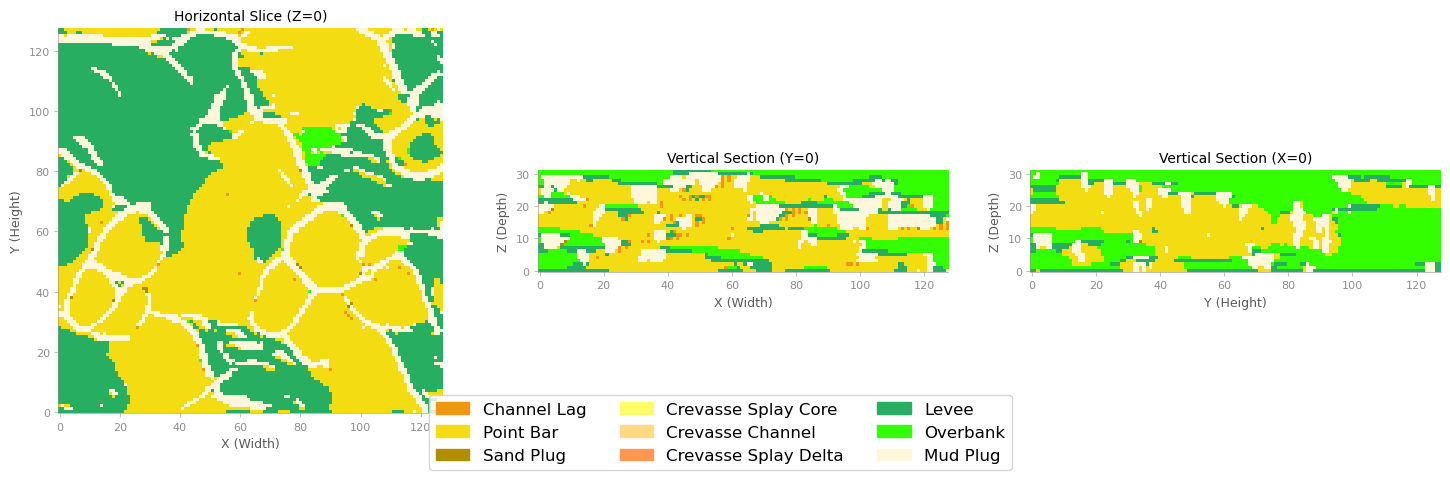

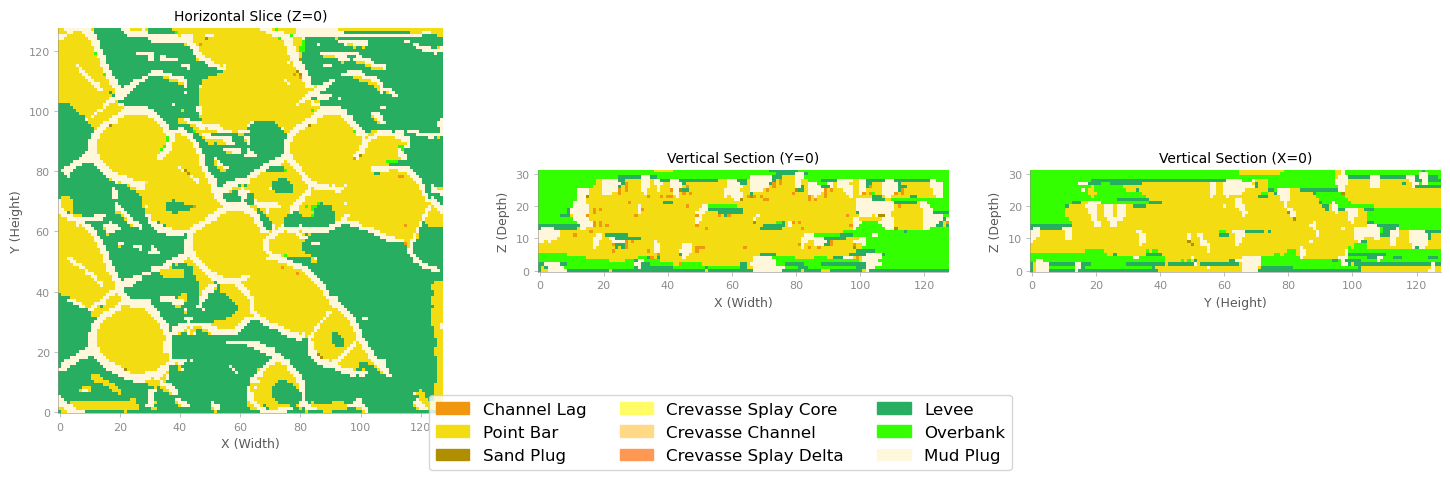

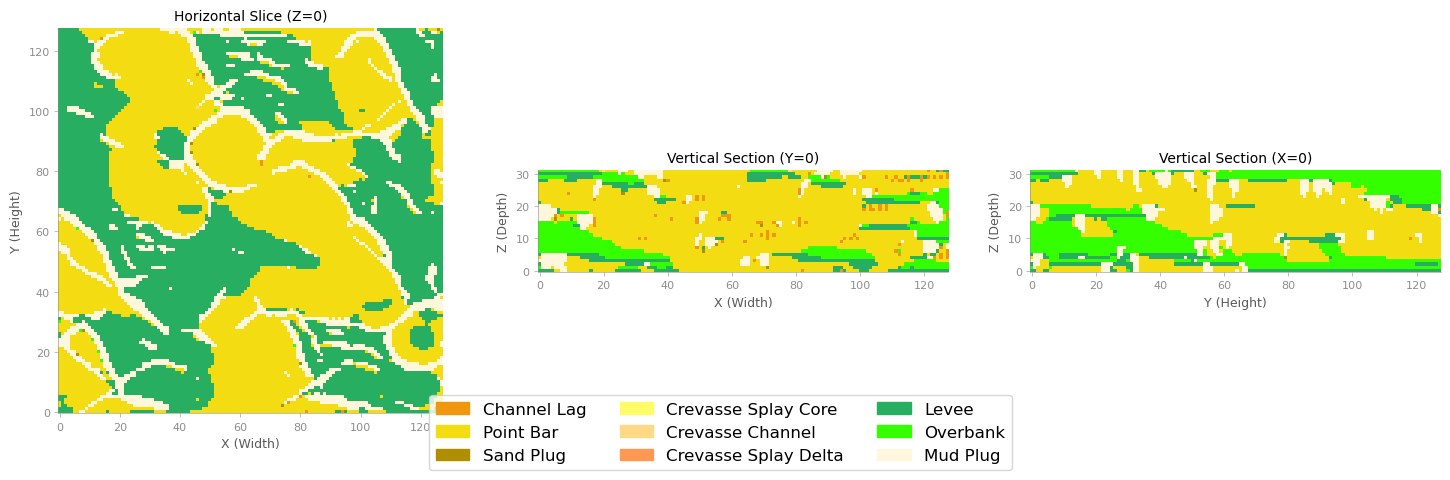


--- Generating Run 1 Normalized Entropy Matrices ---
Theoretical Absolute Max Upper Bound (H_max): 3.1699 bits


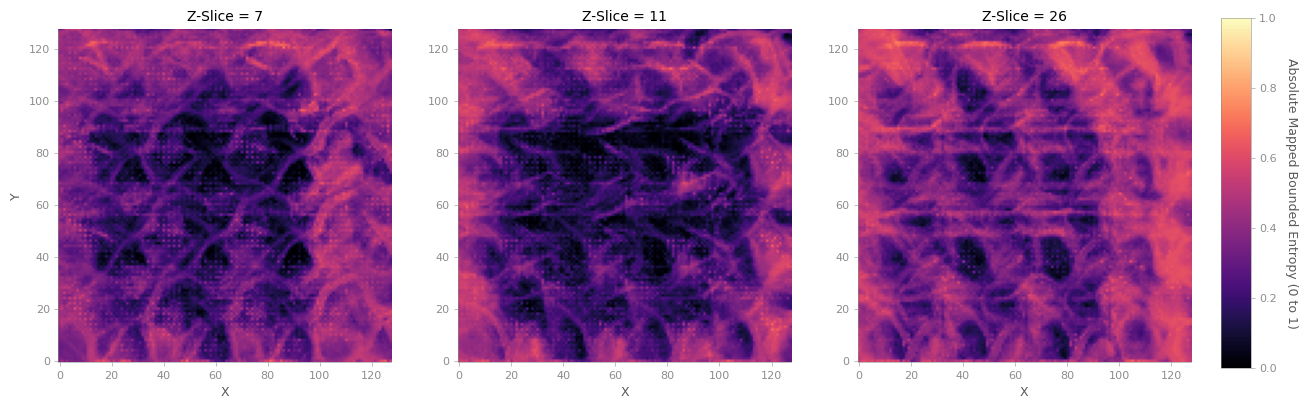

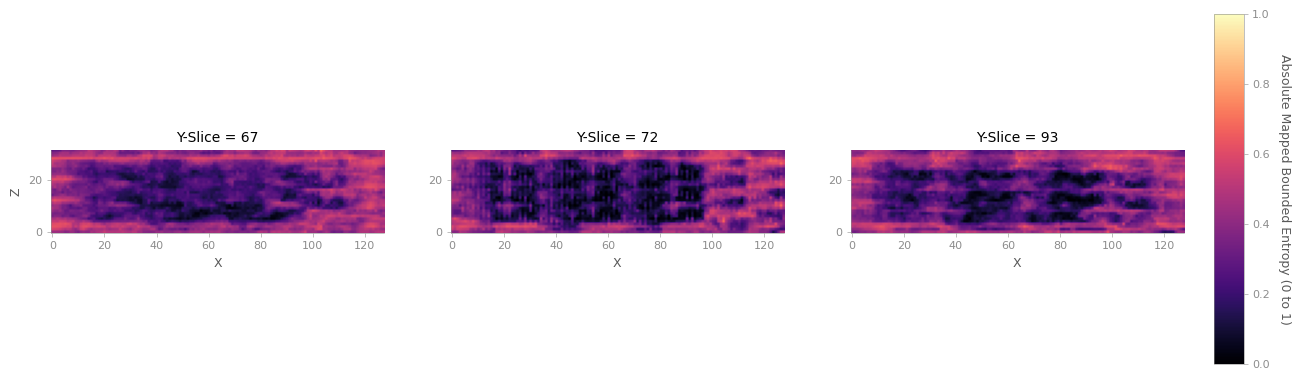

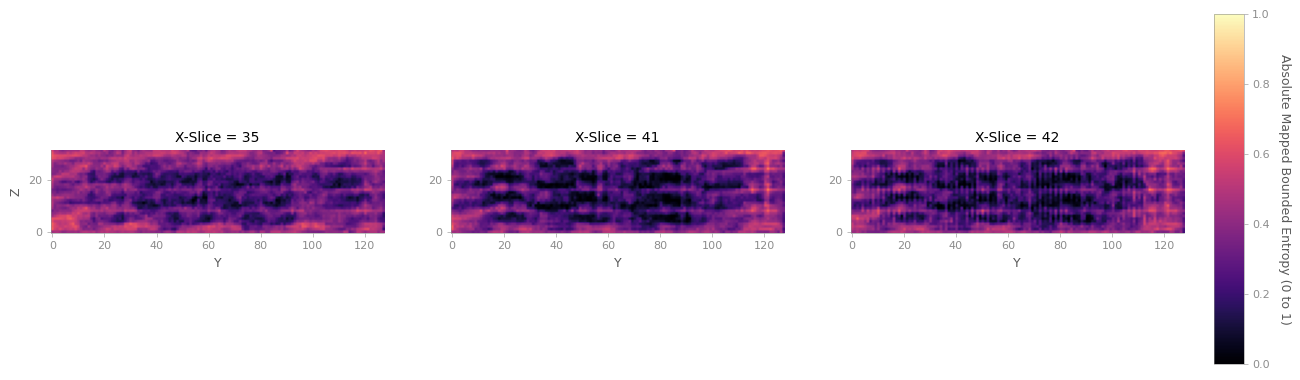


--- Generating Facies Distribution (Mode: GAN) ---


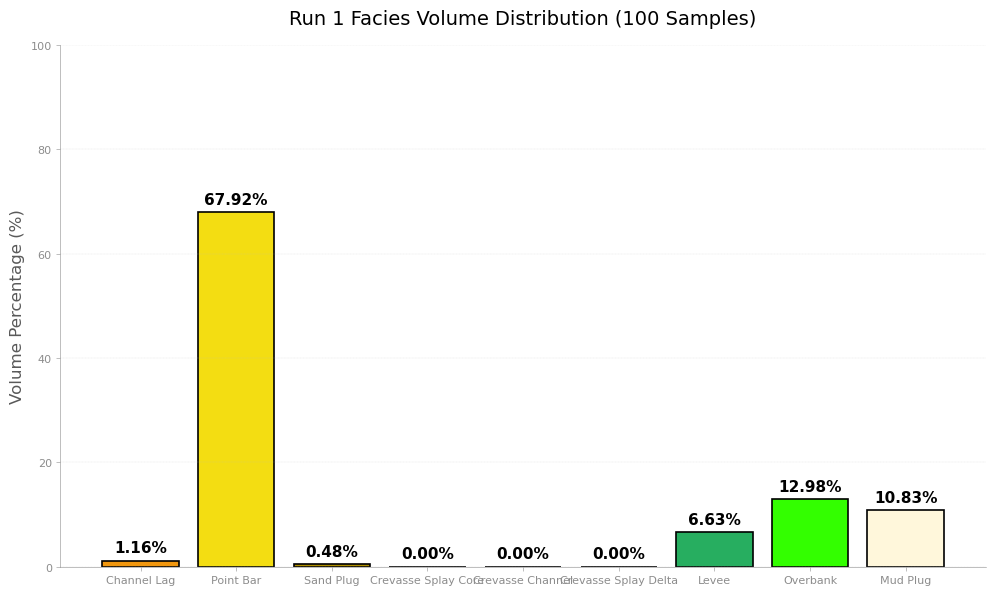


--- Generating 3D PyVista Entropy Map (Run 1) ---
[Run 1] Calculated Mean Voxel-Wise Entropy: 0.3505


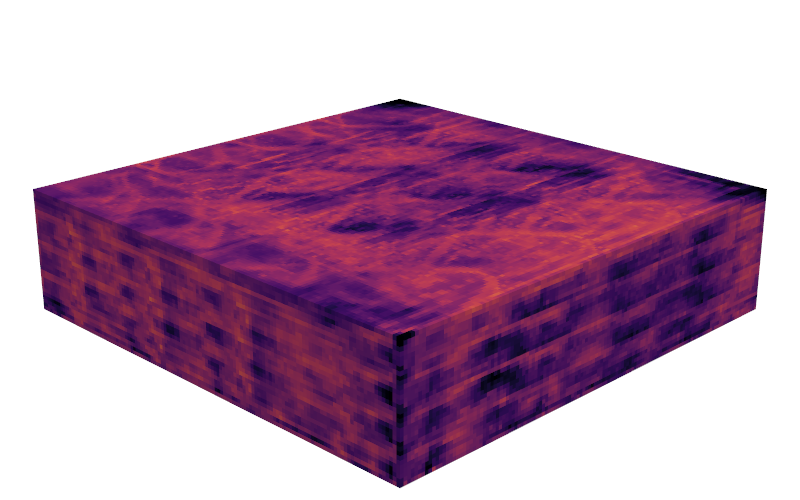

In [8]:
for validator in validators:
    validator.plot_2d_slices(num_samples=3,num_slices=1, save_plot=False)
    validator.plot_entropy(num_slices=3, plot_title=False, save_plot=False)
    validator.plot_facies_percentages(save_plot=False)
    validator.plot_3d_entropy_pyvista(save_plot=False)
    # for i in range(2):
    #    validator.plot_3d_pyvista(mode='combined', show_legend=False ,show_plot=False, save_plot=False)

In [5]:
def plot_metric_history_all_classes(ax, csv_path, run_name):
    """Parses training logs, dynamically handles plotting for N classes, and displays the mean DW value."""
    if not os.path.exists(csv_path):
        ax.text(0.5, 0.5, "Missing History Log", ha='center', va='center', color='orange', fontsize=6)
        ax.axis('off')
        print(f"[{run_name}] Missing History Log - Cannot compute mean SWD")
        return None

    try:
        df = pd.read_csv(csv_path)
        
        # 1. Dynamically find all metric columns (e.g., MS-SWD_Ch0, MS-SWD_Ch1, ..., MS-SWD_Ch8)
        metric_cols = [col for col in df.columns if col.startswith('MS-SWD_Ch')]
        if not metric_cols:
            raise ValueError("No matching 'MS-SWD_Ch' columns found in the CSV.")
            
        # Sort columns to ensure they plot sequentially (Ch0, Ch1, Ch2...)
        metric_cols = sorted(metric_cols, key=lambda x: [int(s) if s.isdigit() else s for s in re.split(r'(\d+)', x)])
        
        # 2. Coerce metric columns to numeric
        for col in metric_cols:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        # Drop rows where the first metric is NaN to cleanly connect validation points
        df_metrics = df.dropna(subset=[metric_cols[0]])
        x_axis = 'iteration'
        
        # 3. Dynamically calculate overall mean SWD across all discovered channels
        channel_means = [df_metrics[col].mean() for col in metric_cols]
        mean_swd = np.mean(channel_means)
        
        # 4. Generate colors dynamically using a matplotlib colormap (handles 3, 9, or N classes beautifully)
        # 'tab10' works perfectly for up to 10 classes. If you have more, 'viridis' or 'plasma' are great alternatives.
        cmap = plt.get_cmap('tab10') 
        
        lines = []
        for i, col in enumerate(metric_cols):
            color = cmap(i % 10)  # Cycles if classes exceed 10
            line, = ax.plot(
                df_metrics[x_axis], 
                df_metrics[col], 
                color=color, 
                linewidth=1.0, 
                markersize=1.5,
                label=col.split('_')[-1] # e.g., 'Ch0', 'Ch1' (useful if you add a legend later)
            )
            lines.append(line)
        
        # Axis titles and inline metrics placement
        ax.set_title(run_name, fontsize=7, pad=4, loc='left')
        ax.text(1.0, 1.05, f"mean $d_w$ = {mean_swd:.3f}", fontsize=6.5, color='#595959', ha='right', va='baseline', transform=ax.transAxes)
        
        ax.legend(
            handles=lines,
            loc='upper right',
            bbox_to_anchor=(0.95, 0.95),  # Keeps it cleanly inside the plot box
            ncol=3,                       # 3x3 grid looks compact and neat inside the axis
            fontsize=5,
            frameon=True,
            facecolor='white',
            edgecolor='#e0e0e0',
            framealpha=0.9,               # Slightly translucent so gridlines behind it show faintly
            handlelength=1.2,
            handletextpad=0.4,
            columnspacing=0.8
        )

        ax.grid(True, linestyle='--', alpha=0.4, linewidth=0.5)
        ax.xaxis.set_major_locator(MaxNLocator(nbins=4, integer=True))
        ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
        ax.tick_params(axis='both', which='major', labelsize=5.5, pad=2)
        
        return lines
        
    except Exception as e:
        ax.text(0.5, 0.5, "Error Processing CSV", ha='center', va='center', color='red', fontsize=6)
        ax.axis('off')
        print(f"[{run_name}] Error processing CSV: {str(e)}")
        return None

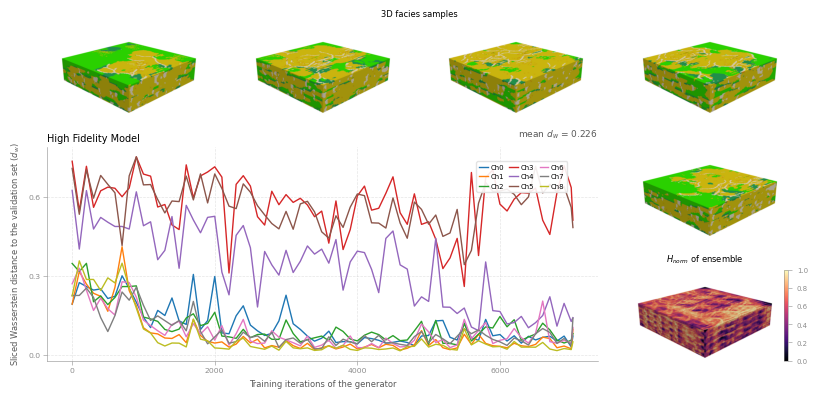

In [28]:
import os
import re
import glob
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.image as mpimg

# 1. Path definition
output_dir_HF = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\plots\post_training_plots\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
gan_dir = r"C:\Users\mathi\Desktop\TU Delft\TU Delft year 5\Master Thesis\Thesis-project-DGM\outputs\post_training\20000_training_samples\25_epochs_9_classes_cgan_lr_1e3_gen_3e3_disc_doubleconv_doubleresblock_on_penalty_every_16_iter_setting_2"
absolute_csv_path = os.path.abspath(os.path.join(gan_dir, "fluvgan_1_training_1_architecture_4_dcgan_one_hot_all_1_history.csv"))

# 2. Create figure
fig = plt.figure(figsize=(8.27, 4))
gs = gridspec.GridSpec(nrows=3, ncols=4)
gs.update(hspace=0.35, wspace=0.18, bottom=0.08, top=0.92, left=0.05, right=0.95) # Slightly increased hspace for titles

# 4. Gather all available sample images
img_pattern = os.path.join(output_dir_HF, "3d_plot_gan_sample_*combined.png")
entropy_pattern = os.path.join(output_dir_HF, "3d_plot_gan_ensemble_entropy.png")
available_images = sorted(glob.glob(img_pattern))
available_entropy = sorted(glob.glob(entropy_pattern))

# 5. Define all 6 empty gridspec slots for the samples
# Top row (4 slots) + Right column remaining slots (2 slots)
sample_slots = [
    gs[0, 0], gs[0, 1], gs[0, 2], gs[0, 3], # Upper row
    gs[1, 3]                      # Right-hand side remaining
]
entropy_slot= gs[2, 3]

if available_images:
    # Dynamically select up to 6 evenly spaced samples across your directory
    indices = np.linspace(0, len(available_images) - 1, len(sample_slots), dtype=int)
    images_to_plot = [available_images[idx] for idx in indices]
    
    for slot, img_path in zip(sample_slots, images_to_plot):
        ax_img = fig.add_subplot(slot)
        
        # Load and display sample
        img = mpimg.imread(img_path)
        ax_img.imshow(img)
        ax_img.axis('off')
else:
    print("No images found matching the pattern.")

if available_entropy:
    ax_ent = fig.add_subplot(entropy_slot)
    
    # 1. Pass the magma colormap to imshow and store the image object in 'im'
    img_data = mpimg.imread(available_entropy[0])
    im = ax_ent.imshow(img_data, cmap='magma')
    ax_ent.axis('off')

    # set title
    ax_ent.set_title("$H_{norm}$ of ensemble", fontsize=6)
    cbar = fig.colorbar(im, ax=ax_ent, fraction=0.046, pad=0.04)
    cbar.ax.tick_params(labelsize=5) 
else:
    print("No entropy images found matching the pattern.")

ax_swd = fig.add_subplot(gs[1:, :3])
ax_swd.set_ylabel(f"Sliced Wasserstein distance to the validation set ($d_w$)", fontsize=6)
ax_swd.set_xlabel(f"Training iterations of the generator", fontsize=6)
lines = plot_metric_history_all_classes(ax=ax_swd, csv_path=absolute_csv_path, run_name='High Fidelity Model')

ax_img_top = fig.add_subplot(gs[0, :])
ax_img_top.axis('off')
ax_img_top.set_title(f"3D facies samples", fontsize=6)

output_save_path = os.path.join(output_dir_HF, "final_combined_plot.png")
plt.savefig(output_save_path, dpi=400, bbox_inches='tight')
plt.show()